# Team members
### 1. Reece Pennington
### 2. Benjamin Valenzuela

# About Dataset
### Data Science Job Salaries Dataset contains 11 columns, each are:

- work_year: The year the salary was paid.
- experience_level: The experience level in the job during the year
- employment_type: The type of employment for the role
- job_title: The role worked in during the year.
- salary: The total gross salary amount paid.
- salary_currency: The currency of the salary paid as an ISO 4217 currency code.
- salaryinusd: The salary in USD
- employee_residence: Employee's primary country of residence in during the work year as an ISO 3166 country code.
- remote_ratio: The overall amount of work done remotely
- company_location: The country of the employer's main office or contracting branch
- company_size: The median number of people that worked for the company during the year

In [4]:
# Install the required libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Steps of EAD
### 1. Loading and Inspecting Data

Core pandas functions:
- df.head()
- df.tail()
- df.shape
- df.columns
- df.info()
- df.describe()
- df.dtypes

In [5]:
#Load the data set and use info() columns shape and head() te get a preview and underestanding of data
salarydf = pd.read_csv("ds_salaries.csv")
salarydf.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [11]:
salarydf.shape

(607, 11)

In [9]:
salarydf.tail()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
602,2022,SE,FT,Data Engineer,154000,USD,154000,US,100,US,M
603,2022,SE,FT,Data Engineer,126000,USD,126000,US,100,US,M
604,2022,SE,FT,Data Analyst,129000,USD,129000,US,0,US,M
605,2022,SE,FT,Data Analyst,150000,USD,150000,US,100,US,M
606,2022,MI,FT,AI Scientist,200000,USD,200000,IN,100,US,L


### 2. Understanding Variables

Categorical vs Numerical Variables

- Continuous vs Discrete

- Nominal vs Ordinal

Useful functions:
- df['column'].unique()
- df['column'].value_counts()
- df['column'].nunique()

In [13]:
salarydf.nunique()

work_year               3
experience_level        4
employment_type         4
job_title              50
salary                272
salary_currency        17
salary_in_usd         369
employee_residence     57
remote_ratio            3
company_location       50
company_size            3
dtype: int64

### 3. Handling Missing Data
Key functions:

- df.isnull()
- df.isnull().sum()
- df.dropna()
- df.fillna()

In [12]:
salarydf.isnull().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

### 4. Descriptive Statistics
Numerical:
- `df.describe()`
- `df.mean()`
- `df.median()`
- `df.std()`
- `df.min()`
- `df.max()`
- `df.quantile()`

Categorical:
- `df["Category"].mode()`
- `df["Category"].describe()`

In [14]:
salarydf.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,6.070000e+02,607.000000,607.00000
mean,2021.405272,3.240001e+05,112297.869852,70.92257
std,0.692133,1.544357e+06,70957.259411,40.70913
min,2020.000000,4.000000e+03,2859.000000,0.00000
25%,2021.000000,7.000000e+04,62726.000000,50.00000
50%,2022.000000,1.150000e+05,101570.000000,100.00000
75%,2022.000000,1.650000e+05,150000.000000,100.00000
max,2022.000000,3.040000e+07,600000.000000,100.00000


### 5. Grouping and Aggregation
Concepts:

- Aggregation
- Multi-level grouping
- Count vs size
- Resetting index

Syntax:
- `df.groupby('Category').mean()`
- `df.groupby(['Category','Gender']).agg(['mean','count'])`

In [32]:
# [Optional] You may choose to perform grouping and aggregation to generate additional results or visualizations for deeper data analysis.
occupationdf = salarydf.groupby('job_title')["salary"].mean().sort_values(ascending = False).reset_index()
occupationdf

,job_title,salary
0,Head of Machine Learning,6.000000e+06
1,ML Engineer,2.676667e+06
2,BI Data Analyst,1.902045e+06
3,Lead Data Scientist,1.101667e+06
4,Data Science Manager,1.062599e+06
5,Lead Data Analyst,5.690000e+05
6,Data Scientist,5.083472e+05
7,Big Data Engineer,4.550000e+05
8,Data Analytics Lead,4.050000e+05
9,3D Computer Vision Researcher,4.000000e+05


### 6. Data Distribution & Visualization
visualization is essential for EAD.

Useful Diagram:
- Countplot
- Barplot
- Lineplot (time trends)
- Histogram
- Boxplot
- pairplot


### Pairwise relationships between numerical variables

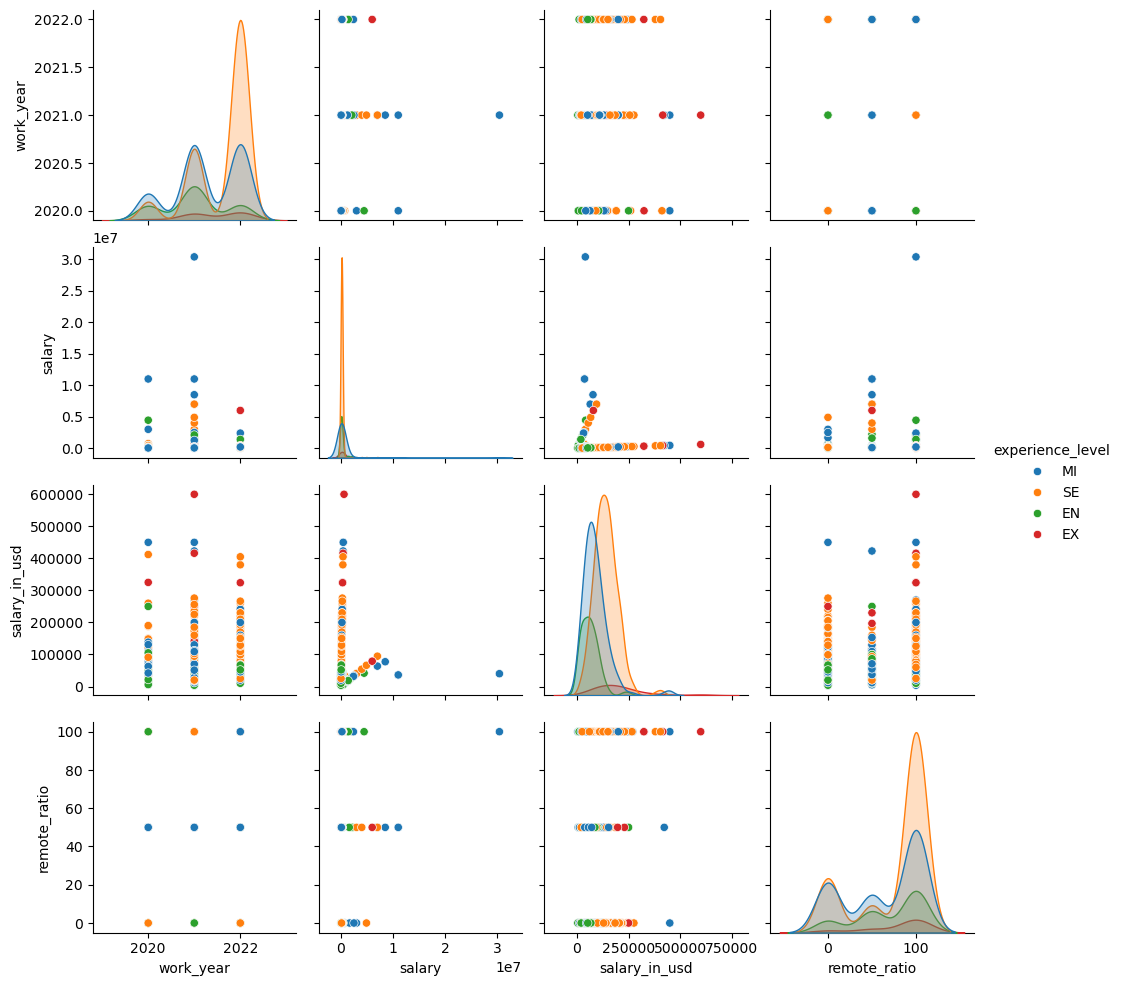

In [35]:
# use hue='experience_level' in your pair plot
sns.pairplot(data=salarydf, hue='experience_level')
plt.show()

### 7. Correlation & Relationships

Useful functions and diagrams:
- `df.corr()`
- `pd.crosstab(df["Category"], df["Another_Category"])`
- `sns.heatmap(df.corr())` 


### Visualize the Correlation map for work_year and salary

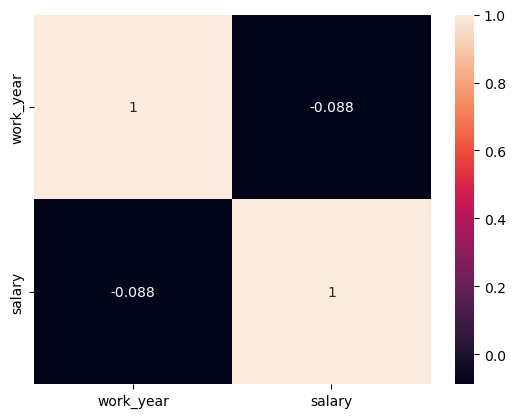

In [38]:
heatmap = salarydf[['work_year','salary']]
matrix = heatmap.corr(method = 'pearson')
sns.heatmap(matrix, annot=True)
plt.show()


### Your Observations:
#### write your observation about above plot in this cell
##### Work year and salary have a very weak negatively correlated relationship. Therefore, commenting on the nature of their relationship is not statistically reliable.

### Create a Barplot to identify which year has the most data scientist salary records in the dataset

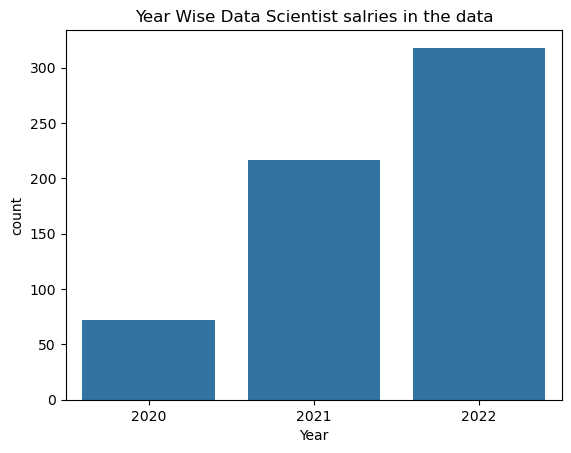

In [43]:
datas = salarydf[salarydf['job_title']=='Data Scientist']
sns.countplot(data=datas, x=salarydf['work_year'])
plt.title('Year Wise Data Scientist salries in the data')
plt.xlabel('Year')
plt.show()

### Your Observations: 
#### write your observation about above plot in this cell
##### In the distribution, 2022 has the highest amount of data scientist salaries. Additionally, there is a visible trend in the data, where the count of data scientist salaries increase yearly. 

### Use a pie chart to show the distribution of experience levels in the dataset.

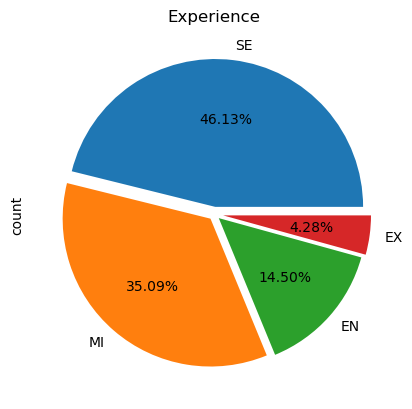

In [49]:
#Use the explode parameter and set it to explode = [0.05, 0.04, 0.05, 0.06] to display the pie chart with separated slices.
salarydf['experience_level'].value_counts().plot(kind='pie',explode = [0.05,0.04,0.04,0.06],autopct='%0.2f%%')
plt.title('Experience')
plt.show()

### Your Observations: 
#### write your observation about above plot in this cell
##### The two largest group of experience levels within the distribution are mid level occupations, and senior level occupations. with executive positions and entry level positions being the two smallest. The largest overall group is the senior level occupation, while the overall smallest is the entry level occupation. 

### Create histogram to understand Salary distribution by Experience level
use salary_in_usd 

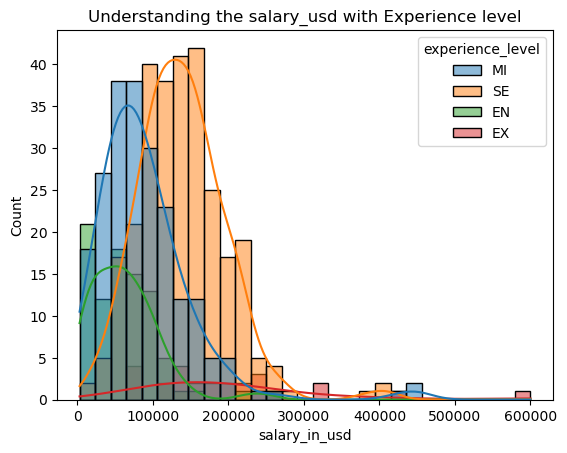

In [52]:
# Use histplot with Kernel density estimate (kde=True) 
sns.histplot(salarydf, x='salary_in_usd', hue ='experience_level', kde=True)
plt.title('Understanding the salary_usd with Experience level')
plt.show()

### Plot a histogram to explore the distribution of data scientist salaries based on company size.

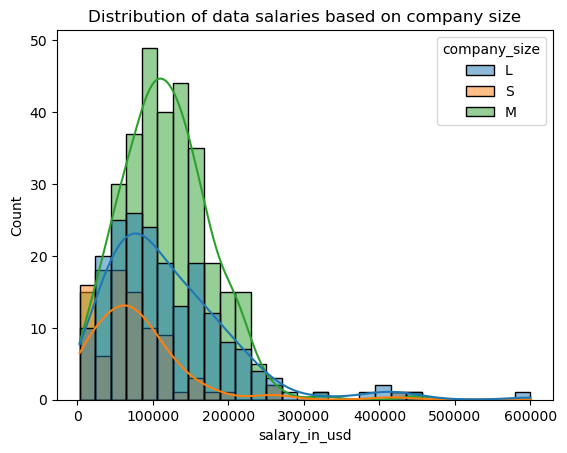

In [57]:
sns.histplot(salarydf, x='salary_in_usd', hue ='company_size', kde=True)
plt.title('Distribution of data salaries based on company size')
plt.show()

### Observations:
#### write your observation about above plot in this cell
##### Both plots appear to be skewed right with high outliers. In the first plot

### Visualize a bar chart showing the average salary of data scientists by experience level.

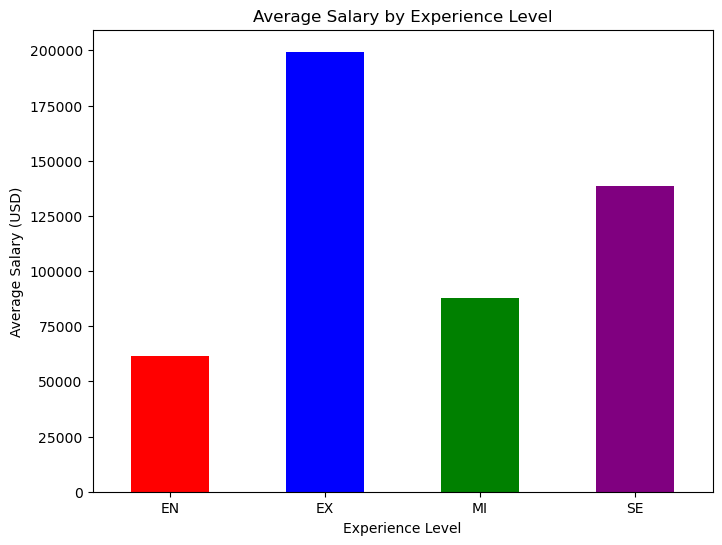

In [65]:
avgs = (
    salarydf.groupby('experience_level')['salary_in_usd']
            .mean()
            .reset_index()
)

# Optional: sort by experience level if needed
# avgs = avgs.sort_values('experience_level')
=
ax = avgs.plot(
    kind='bar',
    x='experience_level',
    y='salary_in_usd',
    color=['Red', 'Blue', 'Green', 'Purple'],
    figsize=(8,6),
    legend=False
)
ax.set_xlabel("Experience Level")
ax.set_ylabel("Average Salary (USD)")
ax.set_title("Average Salary by Experience Level")
plt.xticks(rotation=0)
plt.show()


### Visualize a bar chart showing the average salary of data scientists by job title.

### Observations:
#### write your observation about above plots in this cell


### How much small companys pay for the different roles and who are the highest paid

### Observations:
#### write your observation about above plot in this cell

### Top 10 most demanding job in the USA 

### Find the Average Salary paying the large companys with employement wise

### Observations:
#### write your observations in this cell


# Word Cloud
#### run two following cells

In [ ]:
!pip install wordcloud

In [ ]:
#We import the wordcloud from the 
from wordcloud import WordCloud
text3 = ' '.join(salary_df['job_title'])
wordcloud2 = WordCloud(mode='RGB',background_color='white').generate(text3)

# Generate plot
plt.imshow(wordcloud2)
plt.axis("off")
plt.show()

### Explain what a word cloud is and why we use word clouds. 

### Discuss your observations based on the result of the above code.